# Bônus — LLM + Uncertainty-Aware Router

## Objetivo

Implementar um **router uncertainty-aware** que mantém o **Modelo B** no caminho AUTO (~96% dos chamados) e escala os **top-200 casos difíceis** (critério `D ∨ L`, score `u`) para a **API Rio Open**, com prompt **text-only** (sem predições A/B — anti-anchoring).

> **Ligação com Parte 3:** a recomendação permanece **adotar B**; o router é proposta de **implantação** (quando escalar), não mudança de modelo default.

## Roteiro

1. Setup
2. Seleção top-200 (`uncertainty_score`)
3. Prompt completo (text-only + CoT JSON)
4. API Rio síncrona + fallback B
5. Cache CSV
6. Avaliação (Acc router vs B; Coverage; Acc@AUTO; Acc@LLM)
7. Custo e limitações


## Setup

Imports, caminhos, constantes e carregamento dos 5.000 chamados.


In [1]:
import json
import os
import re
import time
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display, Markdown
from sklearn.metrics import accuracy_score

%matplotlib inline

ROOT = Path("..").resolve()
load_dotenv(ROOT / ".env")

DATA_PATH = ROOT / "dados" / "chamados_com_predicoes.csv"
FIG_DIR = ROOT / "results" / "figures" / "bonus"
CACHE_PATH = ROOT / "results" / "cache" / "llm_predictions.csv"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

TOP_N = 200
CONF_LOW = 0.60
HIGH_RISK = {"esgoto_vazamento", "buraco_via"}
PODA = "poda_arvore"
LABELS = sorted([
    "barulho_perturbacao", "buraco_via", "coleta_lixo", "esgoto_vazamento",
    "estacionamento_irregular", "iluminacao_publica", "poda_arvore", "sinalizacao",
])

RIO_API_KEY = os.getenv("RIO_API_KEY", "")
RIO_API_URL = os.getenv("RIO_API_URL", "https://api.iplan.rio/v1/chat/completions")
RIO_MODEL = os.getenv("RIO_MODEL", "rio-3.0-open-mini")
USE_API = bool(RIO_API_KEY and RIO_API_KEY != "your_api_key_here")

sns.set_theme(style="whitegrid")
df = pd.read_csv(DATA_PATH)
print(f"Chamados: {len(df):,} | API ativa: {USE_API}")


Chamados: 5,000 | API ativa: False


## Seleção top-200 (router offline)

| Sinal | Definição |
|---|---|
| **D(i)** | `pred_modelo_a != pred_modelo_b` |
| **L(i)** | concordam e `conf_modelo_b < 0.60` |
| **u(i)** | `(1-conf_B) + 0.3·D + 0.2·high_risk + 0.15·poda` |
| **E** | top_200({i : D∨L}, u) |

**AUTO:** `pred_final = pred_modelo_b` | **LLM:** API no texto (fallback → B)


In [2]:
def add_router_columns(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["D"] = out["pred_modelo_a"] != out["pred_modelo_b"]
    out["L"] = (~out["D"]) & (out["conf_modelo_b"] < CONF_LOW)
    out["high_risk"] = (
        out["categoria_real"].isin(HIGH_RISK)
        | out["pred_modelo_a"].isin(HIGH_RISK)
        | out["pred_modelo_b"].isin(HIGH_RISK)
    ).astype(int)
    out["poda_involved"] = (
        (out["categoria_real"] == PODA)
        | (out["pred_modelo_a"] == PODA)
        | (out["pred_modelo_b"] == PODA)
    ).astype(int)
    out["u"] = (
        (1 - out["conf_modelo_b"])
        + 0.3 * out["D"].astype(int)
        + 0.2 * out["high_risk"]
        + 0.15 * out["poda_involved"]
    )
    candidates = out[out["D"] | out["L"]]
    escalation_ids = set(candidates.nlargest(TOP_N, "u")["id_chamado"])
    out["route"] = np.where(out["id_chamado"].isin(escalation_ids), "LLM", "AUTO")
    out["escalation_reason"] = np.select(
        [out["D"] & out["L"], out["D"], out["L"]], ["D+L", "D", "L"], default=""
    )
    return out

df = add_router_columns(df)
df_esc = df[df["route"] == "LLM"].sort_values("u", ascending=False)

summary = pd.DataFrame({
    "metrica": ["Candidatos D∨L", "Escalados (LLM)", "AUTO (resto)", "Coverage AUTO"],
    "valor": [
        int((df["D"] | df["L"]).sum()),
        len(df_esc),
        int((df["route"] == "AUTO").sum()),
        f"{(df['route'] == 'AUTO').mean():.1%}",
    ],
})
display(summary)
display(df_esc[["id_chamado", "u", "escalation_reason", "conf_modelo_b", "pred_modelo_a", "pred_modelo_b"]].head(10))


,metrica,valor
0,Candidatos D∨L,1702
1,Escalados (LLM),200
2,AUTO (resto),4800
3,Coverage AUTO,96.0%


,id_chamado,u,escalation_reason,conf_modelo_b,pred_modelo_a,pred_modelo_b
2039,2026001357,1.435,D,0.215,poda_arvore,esgoto_vazamento
3772,2026000005,1.430,D,0.220,esgoto_vazamento,poda_arvore
3186,2026003741,1.405,D,0.245,poda_arvore,esgoto_vazamento
3865,2026004083,1.371,D,0.279,buraco_via,estacionamento_irregular
3907,2026000448,1.356,D,0.294,estacionamento_irregular,poda_arvore
4748,2026004089,1.350,D,0.300,poda_arvore,buraco_via
4486,2026004482,1.328,D,0.122,poda_arvore,estacionamento_irregular
3594,2026002846,1.323,D,0.177,esgoto_vazamento,estacionamento_irregular
2254,2026001015,1.311,D,0.339,esgoto_vazamento,poda_arvore
799,2026003557,1.310,D,0.340,buraco_via,poda_arvore


## Prompt (text-only + CoT JSON)

**Regra anti-anchoring:** o user message contém **somente** o texto do cidadão — nunca `pred_modelo_a`, `pred_modelo_b` ou `conf_*`.

Saída esperada: JSON com `raciocinio_logico` **antes** de `categoria`.


In [3]:
SYSTEM_PROMPT = """Você classifica chamados da Central 1746 do Rio de Janeiro.
Analise APENAS o texto abaixo. Ignore qualquer opinião externa.

Categorias válidas (slug exato):
barulho_perturbacao | buraco_via | coleta_lixo | esgoto_vazamento |
estacionamento_irregular | iluminacao_publica | poda_arvore | sinalizacao

Regras:
- esgoto/vazamento/bueiro → esgoto_vazamento (NÃO buraco_via)
- cratera/asfalto afundado → buraco_via
- galhos/árvore/fiação → poda_arvore

Exemplos:
Texto: "Vazamento de esgoto na calçada, fedor forte."
{"raciocinio_logico": "Menciona esgoto e vazamento.", "categoria": "esgoto_vazamento", "confianca": 0.92}
Texto: "Galhos encostando na fiação elétrica."
{"raciocinio_logico": "Poda de árvore por risco na fiação.", "categoria": "poda_arvore", "confianca": 0.88}

Responda SOMENTE JSON válido:
{
  "raciocinio_logico": "<1-3 frases: evidências no texto>",
  "categoria": "<slug>",
  "confianca": <0.0-1.0>
}"""

display(Markdown(f"**Modelo:** `{RIO_MODEL}` | **temperature:** 0"))


**Modelo:** `rio-3.0-open-mini` | **temperature:** 0

## API Rio síncrona

`httpx.post`, timeout 60s, **1 retry** (sleep 2s). Fallback determinístico → `pred_modelo_b`.


In [4]:
def extract_json_block(content: str) -> str:
    content = content.strip()
    if content.startswith("```"):
        content = re.sub(r"^```(?:json)?\s*", "", content)
        content = re.sub(r"\s*```$", "", content)
    start, end = content.find("{"), content.rfind("}")
    if start == -1 or end == -1:
        raise ValueError("JSON não encontrado")
    return content[start : end + 1]


def classify_rio(texto: str) -> dict:
    payload = {
        "model": RIO_MODEL,
        "temperature": 0,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f'Texto do chamado:\n"{texto}"'},
        ],
    }
    headers = {"Authorization": f"Bearer {RIO_API_KEY}", "Content-Type": "application/json"}
    resp = httpx.post(RIO_API_URL, headers=headers, json=payload, timeout=60.0)
    resp.raise_for_status()
    content = resp.json()["choices"][0]["message"]["content"]
    return json.loads(extract_json_block(content))


def classify_with_fallback(texto: str, pred_b: str) -> dict:
    last_reason = "api_error"
    for attempt in range(2):
        try:
            out = classify_rio(texto)
            cat = out.get("categoria")
            if cat in LABELS:
                return {
                    "pred_rio": cat,
                    "conf_rio": float(out.get("confianca", 0.0)),
                    "raciocinio": out.get("raciocinio_logico", ""),
                    "llm_status": "ok",
                    "fallback_reason": "",
                }
            last_reason = "invalid_slug"
        except (httpx.HTTPError, KeyError, json.JSONDecodeError, ValueError):
            last_reason = "api_error"
        except Exception:
            last_reason = "json_error"
        if attempt == 0:
            time.sleep(2)
    return {
        "pred_rio": pred_b,
        "conf_rio": np.nan,
        "raciocinio": "",
        "llm_status": "fallback_b",
        "fallback_reason": last_reason,
    }


## Cache CSV

`results/cache/llm_predictions.csv` — permite reexecutar **sem** `RIO_API_KEY` se o cache estiver completo.


In [5]:
if CACHE_PATH.exists():
    cache = pd.read_csv(CACHE_PATH)
else:
    cache = pd.DataFrame(columns=["id_chamado", "pred_rio", "conf_rio", "raciocinio", "llm_status", "fallback_reason"])

cached_ids = set(cache["id_chamado"]) if len(cache) else set()
new_rows = []

for row in df_esc.itertuples():
    if row.id_chamado in cached_ids:
        continue
    if USE_API:
        result = classify_with_fallback(row.texto, row.pred_modelo_b)
        time.sleep(0.5)
    else:
        result = {
            "pred_rio": row.pred_modelo_b,
            "conf_rio": np.nan,
            "raciocinio": "",
            "llm_status": "fallback_b",
            "fallback_reason": "no_api_key",
        }
    new_rows.append({"id_chamado": row.id_chamado, **result})

if new_rows:
    cache = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True)
    cache.to_csv(CACHE_PATH, index=False)

print(f"Cache: {len(cache)} linhas | novas chamadas API: {len(new_rows)}")
display(cache["llm_status"].value_counts(dropna=False))


Cache: 200 linhas | novas chamadas API: 0


llm_status
fallback_b    200
Name: count, dtype: int64

## Avaliação

Métricas mínimas MVP: acurácia global router vs A vs B; Coverage; Acc@AUTO; Acc@LLM(A) e Acc@LLM(router); taxa de fallback.


,metrica,valor
0,Acc Modelo A,0.772800
1,Acc Modelo B,0.867600
2,Acc Router,0.867600
3,Coverage AUTO,0.960000
4,Coverage LLM,0.040000
5,Acc@AUTO (B),0.903542
6,Acc@LLM (A),0.750000
7,Acc@LLM (router),0.005000
8,Taxa fallback B,1.000000


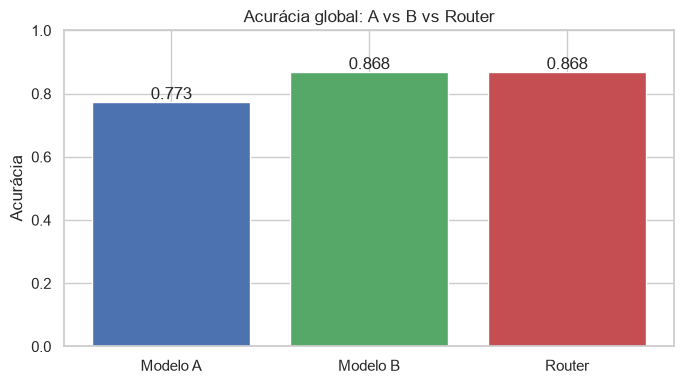

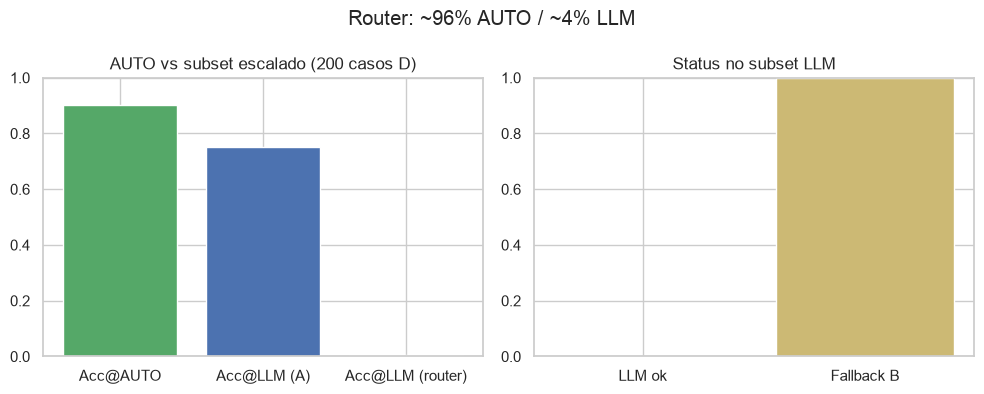

In [6]:
merged = df.merge(cache, on="id_chamado", how="left")
merged["pred_router"] = np.where(
    merged["route"] == "LLM",
    merged["pred_rio"].fillna(merged["pred_modelo_b"]),
    merged["pred_modelo_b"],
)

auto = merged[merged["route"] == "AUTO"]
llm = merged[merged["route"] == "LLM"]

metrics = pd.DataFrame({
    "metrica": [
        "Acc Modelo A", "Acc Modelo B", "Acc Router",
        "Coverage AUTO", "Coverage LLM",
        "Acc@AUTO (B)", "Acc@LLM (A)", "Acc@LLM (router)", "Taxa fallback B",
    ],
    "valor": [
        accuracy_score(merged["categoria_real"], merged["pred_modelo_a"]),
        accuracy_score(merged["categoria_real"], merged["pred_modelo_b"]),
        accuracy_score(merged["categoria_real"], merged["pred_router"]),
        len(auto) / len(merged),
        len(llm) / len(merged),
        accuracy_score(auto["categoria_real"], auto["pred_modelo_b"]),
        accuracy_score(llm["categoria_real"], llm["pred_modelo_a"]),
        accuracy_score(llm["categoria_real"], llm["pred_router"]),
        (llm["llm_status"] == "fallback_b").mean(),
    ],
})
display(metrics)

pred_fallback_a = np.where(
    merged["route"] == "LLM",
    merged["pred_modelo_a"],
    merged["pred_modelo_b"],
)
acc_fb_a = accuracy_score(merged["categoria_real"], pred_fallback_a)
acc_router = metrics.loc[metrics["metrica"] == "Acc Router", "valor"].iloc[0]
b_wrong_llm = (llm["categoria_real"] != llm["pred_modelo_b"]).mean()
print(
    f"Acc router hipotético (fallback A no caminho LLM): {acc_fb_a:.4f} "
    f"(+{(acc_fb_a - acc_router) * 100:.2f} p.p. vs router atual)"
)
print(f"Taxa de erro do B no subset escalado (seleção): {b_wrong_llm:.1%}")

# Figura 1
fig, ax = plt.subplots(figsize=(7, 4))
names, accs = ["Modelo A", "Modelo B", "Router"], [
    metrics.loc[metrics["metrica"] == "Acc Modelo A", "valor"].iloc[0],
    metrics.loc[metrics["metrica"] == "Acc Modelo B", "valor"].iloc[0],
    metrics.loc[metrics["metrica"] == "Acc Router", "valor"].iloc[0],
]
ax.bar(names, accs, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylim(0, 1)
ax.set_ylabel("Acurácia")
ax.set_title("Acurácia global: A vs B vs Router")
for i, v in enumerate(accs):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_acc_router_vs_b.png", dpi=150)
plt.show()

# Figura 2
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(
    ["Acc@AUTO", "Acc@LLM (A)", "Acc@LLM (router)"],
    [
        metrics.loc[metrics["metrica"] == "Acc@AUTO (B)", "valor"].iloc[0],
        metrics.loc[metrics["metrica"] == "Acc@LLM (A)", "valor"].iloc[0],
        metrics.loc[metrics["metrica"] == "Acc@LLM (router)", "valor"].iloc[0],
    ],
    color=["#55A868", "#4C72B0", "#C44E52"],
)
axes[0].set_ylim(0, 1)
axes[0].set_title("AUTO vs subset escalado (200 casos D)")
fb = metrics.loc[metrics["metrica"] == "Taxa fallback B", "valor"].iloc[0]
axes[1].bar(["LLM ok", "Fallback B"], [1 - fb, fb], color=["#8172B3", "#CCB974"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Status no subset LLM")
fig.suptitle("Router: ~96% AUTO / ~4% LLM")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_subset_escalado_breakdown.png", dpi=150)
plt.show()


### Implicação de design

O score `u` prioriza `(1 − conf_B)` e divergência **D** — o top-200 concentra casos em que o **B já erra** (~99,5% no subset escalado). Acc@LLM(B) ≈ 0,5% reflete **seleção**, não só indisponibilidade da API.

| Política | Acc global (hipot.) | Comentário |
|---|---|---|
| Router atual (fallback B no LLM) | ≈ Acc B (~87%) | Alinhado ao AUTO; anula valor do escalonamento sem Rio |
| Fallback **A** no caminho LLM | ≈ **+3 p.p.** vs router atual | Evidência favorece A no subset escalado |

**Fallback B** no MVP é **operacionalmente simples** (default = adotar B), mas **subótimo em acurácia** no caminho escalado. Refinamento baseado em evidência: fallback **A** quando `D`, fila humana, ou LLM real. Isso **não invalida** a troca global A→B.

## Custo e limitações

**Custo aproximado:** ~200 chamadas × (~500 tokens entrada + ~80 saída) ≈ **116k tokens** por execução completa (modelo `rio-3.0-open-mini`).

| Limitação | Impacto |
|---|---|
| **Anti-anchoring** | A/B usados só no router offline; LLM vê só texto |
| **Viés de seleção (`u`)** | Top-200 ≈ casos onde B já erra (~99,5%); Acc@LLM(B) baixa é esperada |
| **Fallback B** | Alinhado ao AUTO, mas **subótimo** no subset escalado (A ≈ **75%** vs B ≈ **0,5%**); fallback A recuperaria ~**+3 p.p.** globais |
| **Dados sintéticos** | Métricas absolutas não generalizam para produção |
| **Amostra 200** | Pool `D∨L` (1.702), mas top-200 são **só D**; 76 casos L nunca escalam — router captura **parcialmente** baixa confiança |
| **Cache sem API** | Com `fallback_b`/`no_api_key`, router ≡ B até rodar com `RIO_API_KEY` |

**Refinamento (produção):** fallback **A** quando `D`, fila REVIEW, ou LLM real — documentado, não implementado no MVP.
